In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

In [3]:
path = './Dataset'
classes, images = [], []
labels = ["Broccoli", "Carrot", "Cucumber", "Tomato"]

In [4]:
def preprocessing(path, size =(200, 200)):
    img = load_img(path, target_size = size)
    img = img_to_array(img)
    img = tf.image.rgb_to_grayscale(img)/255.0
    return img

In [6]:
for i, label in enumerate(labels):
    fd = os.path.join(path, label)
    for img_name in os.listdir(fd)[:500]:
        img_path = os.path.join(fd, img_name)
        images.append(preprocessing(img_path))
        classes.append(i)

In [8]:
x = np.array(images)
y = tf.keras.utils.to_categorical(classes, num_classes = len(labels))

In [ ]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size = 0.8, random_state = 42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, train_size = 0.5, random_state = 42)

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation="relu", padding="same", input_shape=(200,200,1)),
    tf.keras.layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation="relu"),
    
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(len(labels), activation="softmax")
])

In [12]:
model.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics  = ['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 200, 200, 16)      160       
                                                                 
 conv2d_1 (Conv2D)           (None, 200, 200, 16)      2320      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 100, 100, 16)     0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 100, 100, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 50, 50, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 80000)             0

In [13]:
cb = tf.keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 3)
history = model.fit(x_train, y_train, validation_data = (x_val, y_val), epochs = 50, callbacks= cb)

Epoch 1/50
50/50 [==============================] - 54s 1s/step - loss: 1.4156 - accuracy: 0.2869 - val_loss: 1.3660 - val_accuracy: 0.2900
Epoch 2/50
50/50 [==============================] - 64s 1s/step - loss: 1.3553 - accuracy: 0.3200 - val_loss: 1.3372 - val_accuracy: 0.4200
Epoch 3/50
50/50 [==============================] - 65s 1s/step - loss: 1.3037 - accuracy: 0.3681 - val_loss: 1.2867 - val_accuracy: 0.4300
Epoch 4/50
50/50 [==============================] - 63s 1s/step - loss: 1.2881 - accuracy: 0.3706 - val_loss: 1.2653 - val_accuracy: 0.3750
Epoch 5/50
50/50 [==============================] - 49s 988ms/step - loss: 1.1263 - accuracy: 0.4594 - val_loss: 0.9124 - val_accuracy: 0.6950
Epoch 6/50
50/50 [==============================] - 50s 999ms/step - loss: 0.9558 - accuracy: 0.5750 - val_loss: 0.8083 - val_accuracy: 0.7600
Epoch 7/50
50/50 [==============================] - 56s 1s/step - loss: 0.8375 - accuracy: 0.5938 - val_loss: 0.7202 - val_accuracy: 0.7650
Epoch 8/50
50/

In [36]:
model.evaluate(x_test, y_test)

7/7 [==============================] - 1s 187ms/step - loss: 0.5788 - accuracy: 0.8300


[0.5788242220878601, 0.8299999833106995]

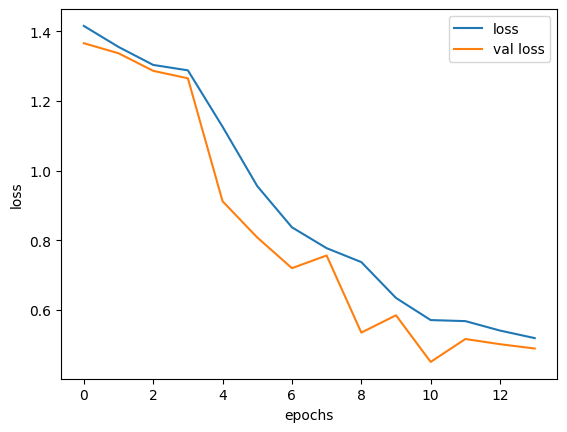

In [37]:
plt.plot(history.history['loss'], label = "loss")
plt.plot(history.history['val_loss'], label = 'val loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

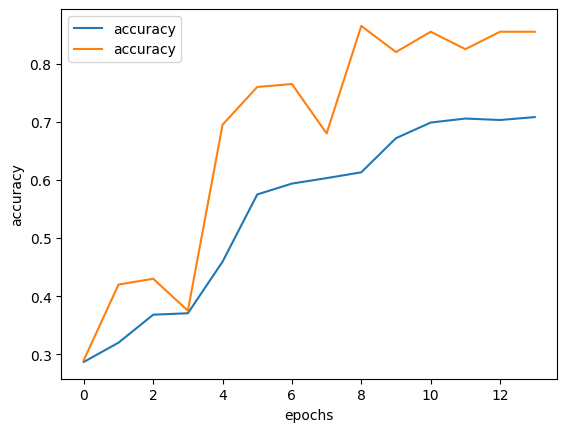

In [38]:
plt.plot(history.history['accuracy'], label = "accuracy")
plt.plot(history.history['val_accuracy'], label = 'accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()